# 10 - Large-Scale LSTM: SHAP Interpretability

Applies SHAP to the tuned LSTM from notebook 09, to identify which of the 15
input features (across the 7-day lookback window) actually drive next-day
temperature predictions. `KernelExplainer` on the flattened sequence input
(model-agnostic, robust across TF/Keras versions), channel-summed across the
7 timesteps for a clean per-feature ranking.


In [1]:
import numpy as np
import pandas as pd
import shap
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from src.data_large import SEQUENCE_FEATURE_COLS

pd.set_option("display.width", 120)

data = np.load("data/processed_large/sequence_windows.npz", allow_pickle=True)
X_trainval, y_trainval = data["X_trainval"], data["y_trainval"]
X_test, y_test = data["X_test"], data["y_test"]

n, k, f = X_trainval.shape
scaler = StandardScaler().fit(X_trainval.reshape(-1, f))
def scale(X):
    shape = X.shape
    return scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype("float32")

X_trainval_s = scale(X_trainval)
X_test_s = scale(X_test)
target_mean, target_std = y_trainval.mean(), y_trainval.std()

model = tf.keras.models.load_model("models/checkpoints_large/final_adam.keras")
print("Loaded tuned LSTM. Input shape:", X_test_s.shape[1:])

Loaded tuned LSTM. Input shape: (7, 15)


## Flatten for KernelExplainer, name columns by (feature, timestep)


In [2]:
N_TIMESTEPS, N_FEATURES = X_trainval_s.shape[1], X_trainval_s.shape[2]

def flatten(X):
    return X.reshape(X.shape[0], -1)

def unflatten(Xf):
    return Xf.reshape(-1, N_TIMESTEPS, N_FEATURES)

def predict_dbt(Xf):
    return model.predict(unflatten(Xf), verbose=0).ravel()

X_trainval_flat = flatten(X_trainval_s)
X_test_flat = flatten(X_test_s)
print("Flattened shapes:", X_trainval_flat.shape, X_test_flat.shape)

# small background (kmeans summary) + a modest explained subset, for tractable runtime
background = shap.kmeans(X_trainval_flat, 30)
rng = np.random.RandomState(42)
explain_idx = rng.choice(len(X_test_flat), size=150, replace=False)
X_explain = X_test_flat[explain_idx]

Flattened shapes: (13142, 105) (1461, 105)


In [3]:
explainer = shap.KernelExplainer(predict_dbt, background)
shap_values = explainer.shap_values(X_explain, nsamples=100, silent=True)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (150, 105)


## Aggregate: sum |SHAP| across the 7 timesteps, per feature

Mirrors the small-dataset project's approach - a fair way to rank which
*feature* matters most regardless of which day in the 7-day window it fell on.


In [4]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)  # (105,)
# reshape order matches unflatten: (timesteps, features) flattened row-major
per_step_per_feat = mean_abs_shap.reshape(N_TIMESTEPS, N_FEATURES)
channel_importance = pd.Series(per_step_per_feat.sum(axis=0), index=SEQUENCE_FEATURE_COLS)
channel_importance = channel_importance.sort_values(ascending=False)
channel_importance

dbt                            0.353419
wbt                            0.217125
temperature_2m_max             0.169229
doy_cos                        0.066492
temperature_2m_min             0.034304
precipitation_sum              0.026944
shortwave_radiation_sum        0.023150
doy_sin                        0.016003
wind_speed_10m_max             0.014071
relative_humidity_2m_mean      0.013525
et0_fao_evapotranspiration     0.013467
vapour_pressure_deficit_max    0.012647
cloud_cover_mean               0.012213
surface_pressure_mean          0.011327
sunshine_duration              0.008449
dtype: float64

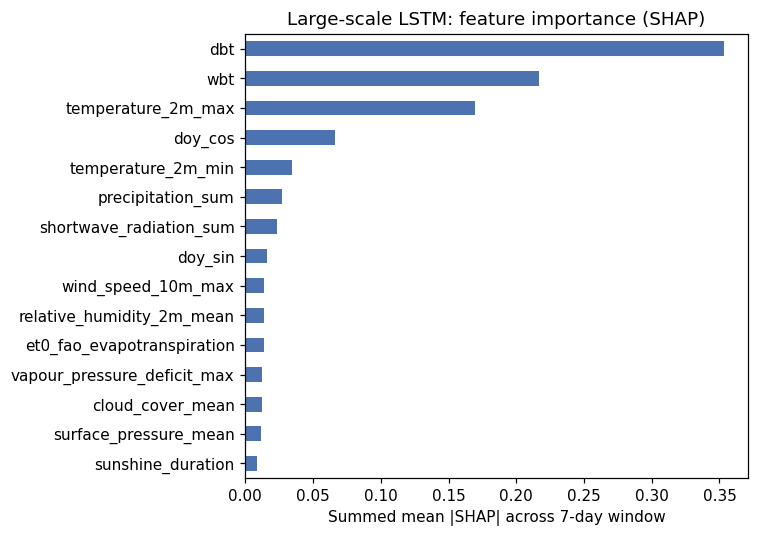

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
channel_importance.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Summed mean |SHAP| across 7-day window")
ax.set_title("Large-scale LSTM: feature importance (SHAP)")
plt.tight_layout()
plt.show()

## Which day in the window matters most for the top feature?

A second view: for the single most important feature, how does its
importance vary by how many days back it was observed (day t-7 .. t-1)?


Top feature overall: dbt
Most important lookback day for it: t-1


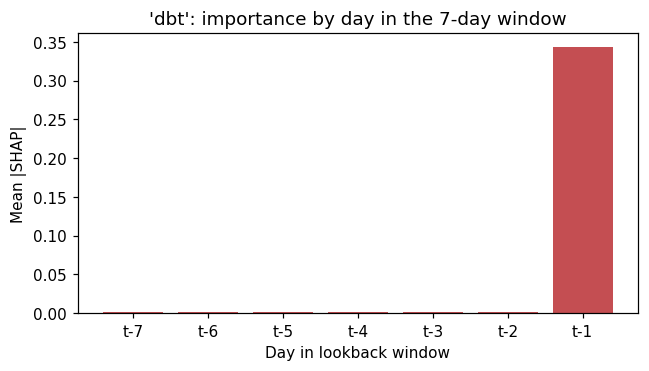

In [6]:
top_feature = channel_importance.index[0]
top_idx = SEQUENCE_FEATURE_COLS.index(top_feature)
by_day = per_step_per_feat[:, top_idx]
day_labels = [f"t-{N_TIMESTEPS-i}" for i in range(N_TIMESTEPS)]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(day_labels, by_day, color="#C44E52")
ax.set_xlabel("Day in lookback window")
ax.set_ylabel("Mean |SHAP|")
ax.set_title(f"'{top_feature}': importance by day in the 7-day window")
plt.tight_layout()
plt.show()

print(f"Top feature overall: {top_feature}")
print(f"Most important lookback day for it: {day_labels[np.argmax(by_day)]}")

In [7]:
import pickle
with open("data/processed_large/shap_results.pkl", "wb") as f:
    pickle.dump({"channel_importance": channel_importance, "per_step_per_feat": per_step_per_feat}, f)
print("Saved data/processed_large/shap_results.pkl")
print()
print("Top 5 features:")
print(channel_importance.head(5))

Saved data/processed_large/shap_results.pkl

Top 5 features:
dbt                   0.353419
wbt                   0.217125
temperature_2m_max    0.169229
doy_cos               0.066492
temperature_2m_min    0.034304
dtype: float64
